# 05 · Neural ODE integration

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE/blob/main/examples/notebooks/05_neural_ode.ipynb)

A Neural ODE replaces a stack of discrete layers with a single learned
derivative `dz/dt = f(t, z)`, integrated by a numerical solver. This
repository's solver, `hmb_kuramoto_ode.models.ode_solver.integrate`, is a
fixed-step, fully differentiable Euler/RK4 implementation: every
intermediate stage stays on the autograd graph, so gradients flow through
the *entire* integration, not just the final state. This notebook checks
that claim quantitatively, fits a parameter through the solver, and finally
runs the project's real vector field through it.

In [1]:
# --- Setup -------------------------------------------------------------
# Makes the project importable whether this notebook runs standalone in
# Google Colab or from a local checkout, then imports the shared libraries
# used throughout. Safe to re-run.
import os
import sys
import subprocess

REPO_URL = "https://github.com/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE.git"


def _locate_repo():
    for candidate in (".", "..", "../..", "repo"):
        path = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(path, "hmb_kuramoto_ode")):
            return path
    # A sparse, blobless clone: this repository also bundles a ~490 MB STEW
    # dataset/ folder (see notebook 07), which this notebook does not need.
    subprocess.run(
        ["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
         "--no-checkout", "--sparse", REPO_URL, "repo"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "sparse-checkout", "init", "--cone"], check=True)
    subprocess.run(
        ["git", "-C", "repo", "sparse-checkout", "set", "hmb_kuramoto_ode", "examples", "configs", "pyproject.toml"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "checkout", "--quiet"], check=True)
    return os.path.abspath("repo")


REPO_DIR = _locate_repo()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch>=2.5,<3", "numpy>=2,<3", "scipy>=1.14,<2", "scikit-learn>=1.5,<2", "matplotlib>=3.9,<4"],
    check=True,
)

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from hmb_kuramoto_ode.utils.seed import seed_everything

print(f"repository: {REPO_DIR}")
print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


repository: /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE
torch 2.13.0 | CUDA available: False


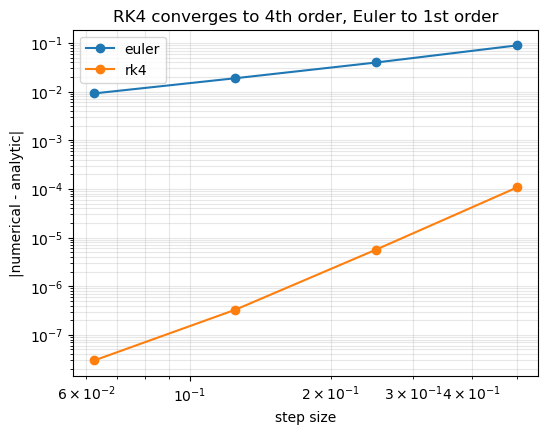

euler: halving the step size divides the error by about 2.0x
rk4: halving the step size divides the error by about 11.0x


In [2]:
from hmb_kuramoto_ode.models.ode_solver import integrate

a_true = -0.8
def linear_field(t, y):
    return a_true * y

t1 = 1.0
analytic = torch.exp(torch.tensor(a_true * t1))

# Stop at step=0.0625: smaller RK4 steps push the error below float32's
# ~1e-7 relative precision floor, where rounding noise (not truncation
# error) dominates and the 4th-order trend below stops holding.
step_sizes = [0.5, 0.25, 0.125, 0.0625]
errors = {"euler": [], "rk4": []}
for step in step_sizes:
    for method in errors:
        y = integrate(linear_field, torch.tensor(1.0), t1=t1, step_size=step, method=method)
        errors[method].append(abs(float(y) - float(analytic)))

fig, ax = plt.subplots(figsize=(6, 4.5))
for method, values in errors.items():
    ax.loglog(step_sizes, values, marker="o", label=method)
ax.set(xlabel="step size", ylabel="|numerical - analytic|",
       title="RK4 converges to 4th order, Euler to 1st order")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()

for method, values in errors.items():
    ratio = values[-2] / values[-1]
    print(f"{method}: halving the step size divides the error by about {ratio:.1f}x")


## Backpropagating through the solver

Now treat the ODE's rate as a learnable `nn.Parameter` and fit it so that
`y(1)` matches a target value, purely by backpropagating through every RK4
stage of `integrate`. This is the same mechanism the full model uses to
learn frequencies, coupling strengths, and gates — the ODE is part of the
computational graph, not a black box.

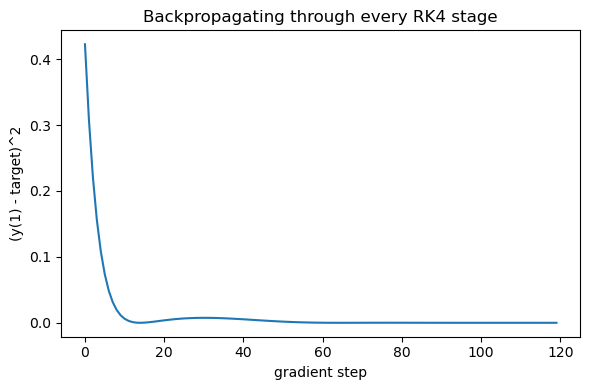

fitted rate:      -1.0521
analytic optimum: -1.0498  (= ln(target), since y(1) = exp(rate))


In [3]:
seed_everything(7)
target = torch.tensor(0.35)
rate = nn.Parameter(torch.tensor(0.0))
optimizer = torch.optim.Adam([rate], lr=0.1)


def field(t, y):
    return rate * y


loss_history = []
for step in range(120):
    optimizer.zero_grad()
    y1 = integrate(field, torch.tensor(1.0), t1=1.0, step_size=0.05, method="rk4")
    loss = (y1 - target) ** 2
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history)
ax.set(xlabel="gradient step", ylabel="(y(1) - target)^2", title="Backpropagating through every RK4 stage")
fig.tight_layout()
plt.show()

fitted_a = rate.item()
true_a = float(torch.log(target))
print(f"fitted rate:      {fitted_a:.4f}")
print(f"analytic optimum: {true_a:.4f}  (= ln(target), since y(1) = exp(rate))")


## The real vector field, integrated

Finally, run `KuramotoGrandVectorField` — the actual Kuramoto+GRAND+attention
dynamics used by the full model — through the same solver on a small
hierarchical graph, and track the angular coordinate (latent dim 0) of every
node across the integration.

RK4 over 10 steps used 40 function evaluations (4 per step)


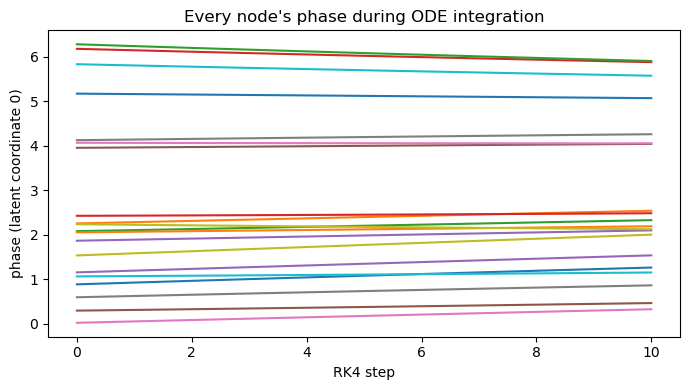

In [4]:
from hmb_kuramoto_ode.data.graph_builder import build_hierarchical_graph
from hmb_kuramoto_ode.models.ode_func import KuramotoGrandVectorField

seed_everything(3)
REGIONS = 4
edge_index, _ = build_hierarchical_graph(REGIONS)
num_nodes = REGIONS * 5
hidden = 6

field = KuramotoGrandVectorField(hidden, edge_index)
z0 = torch.randn(num_nodes, hidden) * 0.3
z0[:, 0] = torch.rand(num_nodes) * 2 * torch.pi  # angular coordinate, as the encoder would set it

field.nfe = 0
_, trajectory = integrate(field, z0, t1=0.2, step_size=0.02, method="rk4", return_trajectory=True)
print(f"RK4 over {trajectory.shape[0] - 1} steps used {field.nfe} function evaluations (4 per step)")

fig, ax = plt.subplots(figsize=(7, 4))
phase_trajectory = trajectory[:, :, 0].detach().numpy()  # angular coordinate over time, all nodes
ax.plot(phase_trajectory)
ax.set(xlabel="RK4 step", ylabel="phase (latent coordinate 0)", title="Every node's phase during ODE integration")
fig.tight_layout()
plt.show()


## Key takeaway

The solver counts vector-field evaluations (`nfe`) and keeps every one of
them differentiable — RK4 costs 4 evaluations per step for a 4th-order
accuracy gain, and that whole chain backpropagates. This is what "the ODE
is part of the computational graph" means concretely, and it's the same
`integrate()` call used inside `HierarchicalKuramotoODE.forward` in
notebook 06.